In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [17]:
TRAIN_START = "2020-01-01"
TRAIN_END = "2025-06-30"

TEST_START = "2025-07-01"
TEST_END = "2026-06-30"

TRAIN = pd.date_range(start=TRAIN_START, end=TRAIN_END)
TEST = pd.date_range(start=TEST_START, end=TEST_END)

In [3]:
# Remove SHIB-USD since it has inf value
ticker_universe = ["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD", "SOL-USD", "TRX-USD", "ZEC-USD", "DOGE-USD", "XMR-USD", "LINK-USD", "ADA-USD", "XLM-USD", "BCH-USD", "LTC-USD", "NEAR-USD", "AVAX-USD", "HBAR-USD", "KCS-USD", "ALGO-USD", "DASH-USD"]

In [4]:
daily_prices = yf.download(tickers=ticker_universe, period="max", interval="1d")

[*********************100%***********************]  20 of 20 completed


In [7]:
daily_returns = daily_prices["Close"].pct_change(fill_method=None)
daily_volumes = daily_prices["Volume"]

In [25]:
weight_lag = 2

In [67]:
def featureX(ticker="BTC-USD", DATE_RANGE=TRAIN, disjoint=True):
    df = pd.DataFrame()
    # 14 day rolling average of daily returns
    df["14_AVG_RET"] = daily_returns.shift().rolling(14).mean()[ticker]
    # Reciprocal of 14 day rolling volatility
    df["INV_14_VOL"] = 1 / daily_returns.shift().rolling(14).std()[ticker]

    return df.loc[DATE_RANGE].loc[::weight_lag].iloc[:-weight_lag] if disjoint else df.loc[DATE_RANGE].iloc[:-weight_lag]

feature_x = featureX()
feature_x

,14_AVG_RET,INV_14_VOL
2020-01-01,0.006142,32.860117
2020-01-03,-0.002041,56.208655
2020-01-05,0.002389,43.720671
2020-01-07,0.004145,44.530695
2020-01-09,0.007822,38.967893
...,...,...
2025-06-17,0.000782,52.579389
2025-06-19,0.000284,50.599170
2025-06-21,-0.000617,60.313641
2025-06-23,-0.003190,60.480818


In [86]:
def featureY(ticker="BTC-USD", DATE_RANGE=TRAIN):
    return daily_returns[ticker][::-1].rolling(window=weight_lag).sum()[::-1].loc[DATE_RANGE].loc[::weight_lag].iloc[:-weight_lag]

feature_y = featureY()
feature_y

2020-01-01   -0.028905
2020-01-03    0.060407
2020-01-05    0.048380
2020-01-07    0.040505
2020-01-09    0.011636
                ...   
2025-06-17   -0.017861
2025-06-19   -0.015029
2025-06-21   -0.022607
2025-06-23    0.049889
2025-06-25    0.008669
Freq: 2D, Name: BTC-USD, Length: 1002, dtype: float64

In [61]:
pd.concat({
    "featureX": feature_x,
    "featureY": feature_y
}, axis=1)

featureX             featureY
           14_AVG_RET INV_14_VOL   BTC-USD
2020-01-01   0.006142  32.860117 -0.028905
2020-01-03  -0.002041  56.208655  0.060407
2020-01-05   0.002389  43.720671  0.048380
2020-01-07   0.004145  44.530695  0.040505
2020-01-09   0.007822  38.967893  0.011636
...               ...        ...       ...
2025-06-17   0.000782  52.579389 -0.017861
2025-06-19   0.000284  50.599170 -0.015029
2025-06-21  -0.000617  60.313641 -0.022607
2025-06-23  -0.003190  60.480818  0.049889
2025-06-25  -0.002641  57.920938  0.008669

[1002 rows x 3 columns]

In [49]:
def Regression(ticker="BTC-USD"):
    X = featureX(ticker).dropna()
    Y = featureY(ticker).dropna()
    common_index = X.index.intersection(Y.index)
    regression_model = sm.OLS(Y.loc[common_index], X.loc[common_index]).fit()
    return regression_model

regression_parameters = pd.DataFrame({ticker: Regression(ticker).params for ticker in ticker_universe})
regression_parameters

,BTC-USD,ETH-USD,BNB-USD,XRP-USD,SOL-USD,TRX-USD,ZEC-USD,DOGE-USD,XMR-USD,LINK-USD,ADA-USD,XLM-USD,BCH-USD,LTC-USD,NEAR-USD,AVAX-USD,HBAR-USD,KCS-USD,ALGO-USD,DASH-USD
14_AVG_RET,0.208171,0.126938,0.48465,0.297536,0.412798,-0.119437,0.018432,0.430609,-0.101105,-0.060462,0.407629,0.320293,0.039208,-0.285622,0.199167,0.472881,0.429816,0.45176,0.26670,-0.025103
INV_14_VOL,0.000072,0.000120,0.00006,0.000119,0.000247,0.000081,0.000075,0.000195,0.000067,0.000180,0.000105,0.000049,0.000099,0.000087,0.000114,0.000121,0.000130,0.00003,0.00008,0.000029


In [68]:
def momentumWeights(DATE_RANGE=TRAIN):
    signal = pd.DataFrame({ticker: (featureX(ticker, DATE_RANGE, disjoint=False) * regression_parameters[ticker]).sum(axis=1) for ticker in ticker_universe})
    ranked = signal.rank(axis=1)
    demeaned =  ranked.sub(ranked.mean(axis=1), axis=0)
    weights = demeaned.div(demeaned.abs().sum(axis=1), axis=0)
    lagged_weights = weights.iloc[::weight_lag].reindex(weights.index, method="ffill")
    return lagged_weights

train_momentum_weights = momentumWeights()
train_momentum_weights

,BTC-USD,ETH-USD,BNB-USD,XRP-USD,SOL-USD,TRX-USD,ZEC-USD,DOGE-USD,XMR-USD,LINK-USD,ADA-USD,XLM-USD,BCH-USD,LTC-USD,NEAR-USD,AVAX-USD,HBAR-USD,KCS-USD,ALGO-USD,DASH-USD
2020-01-01,0.025,0.055,0.075,0.085,-0.075,-0.035,0.005,0.095,-0.015,0.065,0.045,-0.005,0.015,-0.055,-0.075,-0.075,-0.095,0.035,-0.025,-0.045
2020-01-02,0.025,0.055,0.075,0.085,-0.075,-0.035,0.005,0.095,-0.015,0.065,0.045,-0.005,0.015,-0.055,-0.075,-0.075,-0.095,0.035,-0.025,-0.045
2020-01-03,0.045,0.065,-0.015,0.085,-0.065,-0.005,0.035,0.095,0.015,0.075,0.055,-0.025,0.025,0.005,-0.065,-0.065,-0.095,-0.085,-0.035,-0.045
2020-01-04,0.045,0.065,-0.015,0.085,-0.065,-0.005,0.035,0.095,0.015,0.075,0.055,-0.025,0.025,0.005,-0.065,-0.065,-0.095,-0.085,-0.035,-0.045
2020-01-05,0.045,0.055,0.035,0.085,-0.075,-0.005,0.005,0.095,-0.035,0.075,0.065,-0.025,0.025,-0.045,-0.075,-0.075,-0.095,0.015,-0.015,-0.055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-24,0.055,0.005,0.025,0.035,0.045,0.085,-0.015,-0.035,0.065,0.095,-0.075,-0.065,0.015,0.075,-0.045,-0.095,-0.085,-0.005,-0.055,-0.025
2025-06-25,0.065,0.005,0.015,0.045,0.035,0.085,-0.005,-0.035,0.055,0.075,-0.085,-0.065,0.025,0.095,-0.045,-0.095,-0.075,-0.015,-0.055,-0.025
2025-06-26,0.065,0.005,0.015,0.045,0.035,0.085,-0.005,-0.035,0.055,0.075,-0.085,-0.065,0.025,0.095,-0.045,-0.095,-0.075,-0.015,-0.055,-0.025
2025-06-27,0.085,0.015,0.035,0.025,0.055,0.095,-0.025,-0.005,0.045,0.075,-0.085,-0.075,0.005,0.065,-0.055,-0.095,-0.065,-0.015,-0.035,-0.045


In [74]:
def netMomentum(momentum_weights, DATE_RANGE=TRAIN):
    return (momentum_weights * daily_returns.loc[DATE_RANGE]).subtract((momentum_weights - momentum_weights.shift()).abs() * 0.002, fill_value=0).sum(axis=1)

train_net_momentum = netMomentum(train_momentum_weights, DATE_RANGE=TRAIN)
train_net_momentum

2020-01-01   -0.001492
2020-01-02   -0.005065
2020-01-03    0.008764
2020-01-04   -0.008964
2020-01-05   -0.004786
                ...   
2025-06-26    0.009307
2025-06-27   -0.004587
2025-06-28    0.000400
2025-06-29    0.000000
2025-06-30    0.000000
Freq: D, Length: 2008, dtype: float64

In [75]:
def sharpeRatio(x):
    return x.mean() / x.std() * np.sqrt(252)

<Axes: title={'center': 'Training Net Sharpe (1.47 Overall)'}, xlabel='Financial Quarter', ylabel='Sharpe Ratio'>

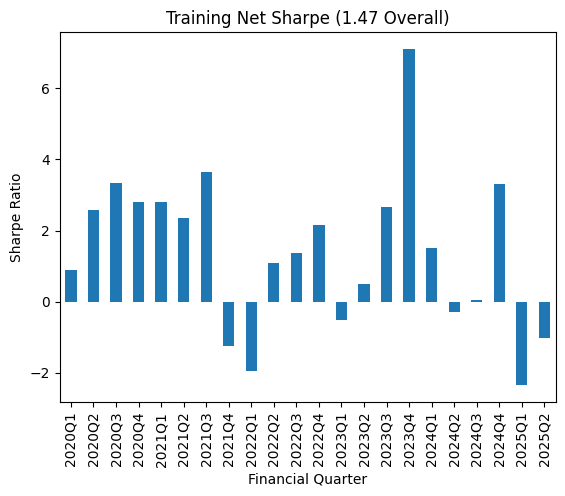

In [ ]:
train_net_momentum.resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar", title=f"Train Net Sharpe ({sharpeRatio(train_net_momentum):.2f} Overall)", ylabel="Sharpe Ratio", xlabel="Financial Quarter")

In [81]:
test_momentum_weights = momentumWeights(DATE_RANGE=TEST)
test_momentum_weights

,BTC-USD,ETH-USD,BNB-USD,XRP-USD,SOL-USD,TRX-USD,ZEC-USD,DOGE-USD,XMR-USD,LINK-USD,ADA-USD,XLM-USD,BCH-USD,LTC-USD,NEAR-USD,AVAX-USD,HBAR-USD,KCS-USD,ALGO-USD,DASH-USD
2025-07-01,0.075,0.015,0.065,0.035,0.095,0.085,-0.055,0.045,0.005,0.055,-0.085,-0.095,-0.015,0.025,-0.045,-0.065,-0.035,-0.025,-0.005,-0.075
2025-07-02,0.075,0.015,0.065,0.035,0.095,0.085,-0.055,0.045,0.005,0.055,-0.085,-0.095,-0.015,0.025,-0.045,-0.065,-0.035,-0.025,-0.005,-0.075
2025-07-03,0.075,0.005,0.045,0.065,0.095,0.085,-0.075,0.055,-0.045,0.025,-0.065,-0.095,-0.015,-0.055,-0.035,0.015,0.035,-0.025,-0.005,-0.085
2025-07-04,0.075,0.005,0.045,0.065,0.095,0.085,-0.075,0.055,-0.045,0.025,-0.065,-0.095,-0.015,-0.055,-0.035,0.015,0.035,-0.025,-0.005,-0.085
2025-07-05,0.055,-0.005,0.035,0.085,0.095,0.065,-0.075,0.075,-0.045,0.025,-0.025,-0.085,0.005,-0.065,-0.015,0.015,0.045,-0.055,-0.035,-0.095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-24,0.025,0.045,-0.035,0.005,0.095,0.075,-0.065,0.065,-0.075,0.085,-0.085,-0.045,-0.025,0.015,-0.055,-0.015,0.055,0.035,-0.005,-0.095
2026-06-25,0.025,0.045,-0.035,0.005,0.095,0.075,-0.065,0.065,-0.075,0.085,-0.085,-0.045,-0.025,0.015,-0.055,-0.015,0.055,0.035,-0.005,-0.095
2026-06-26,0.015,0.045,-0.055,0.005,0.085,0.075,-0.045,0.065,0.025,0.095,-0.095,-0.085,-0.005,0.055,-0.065,-0.035,0.035,-0.015,-0.025,-0.075
2026-06-27,0.015,0.045,-0.055,0.005,0.085,0.075,-0.045,0.065,0.025,0.095,-0.095,-0.085,-0.005,0.055,-0.065,-0.035,0.035,-0.015,-0.025,-0.075


In [82]:
test_net_momentum = netMomentum(test_momentum_weights, DATE_RANGE=TEST)
test_net_momentum

2025-07-01    0.008045
2025-07-02   -0.014124
2025-07-03   -0.004628
2025-07-04    0.001438
2025-07-05    0.000526
                ...   
2026-06-26    0.002736
2026-06-27    0.004346
2026-06-28    0.005725
2026-06-29    0.000000
2026-06-30    0.000000
Freq: D, Length: 365, dtype: float64

<Axes: title={'center': 'Test Net Sharpe (-1.54 Overall)'}, xlabel='Month', ylabel='Sharpe Ratio'>

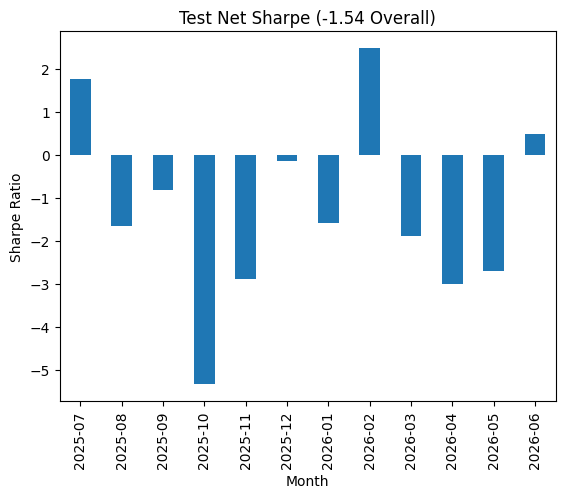

In [85]:
test_net_momentum.resample("ME").apply(sharpeRatio).to_period("M").plot(kind="bar", title=f"Test Net Sharpe ({sharpeRatio(test_net_momentum):.2f} Overall)", ylabel="Sharpe Ratio", xlabel="Month")